# **NETFLIX MOVIES AND TV SHOWS**

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

**1. Load dataset**

In [2]:
df=pd.read_csv('/content/NETFLIX MOVIES AND TV SHOWS CLUSTERING.csv')

In [3]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,TV Show,3%,NaN,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,"August 14, 2020",2020,TV-MA,4 Seasons,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...
1,s2,Movie,7:19,Jorge Michel Grau,"Demián Bichir, Héctor Bonilla, Oscar Serrano, ...",Mexico,"December 23, 2016",2016,TV-MA,93 min,"Dramas, International Movies",After a devastating earthquake hits Mexico Cit...
2,s3,Movie,23:59,Gilbert Chan,"Tedd Chan, Stella Chung, Henley Hii, Lawrence ...",Singapore,"December 20, 2018",2011,R,78 min,"Horror Movies, International Movies","When an army recruit is found dead, his fellow..."
3,s4,Movie,9,Shane Acker,"Elijah Wood, John C. Reilly, Jennifer Connelly...",United States,"November 16, 2017",2009,PG-13,80 min,"Action & Adventure, Independent Movies, Sci-Fi...","In a postapocalyptic world, rag-doll robots hi..."
4,s5,Movie,21,Robert Luketic,"Jim Sturgess, Kevin Spacey, Kate Bosworth, Aar...",United States,"January 1, 2020",2008,PG-13,123 min,Dramas,A brilliant group of students become card-coun...


In [4]:
df.shape

(7787, 12)

In [5]:
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,2389
cast,718
country,507
date_added,10
release_year,0
rating,7
duration,0


**2. Data Cleaning**

In [6]:

df.dropna(inplace=True)

In [7]:
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,0
cast,0
country,0
date_added,0
release_year,0
rating,0
duration,0


In [8]:
df['duration'].value_counts()

,count
duration,
93 min,121
94 min,119
90 min,114
95 min,111
97 min,107
...,...
253 min,1
190 min,1
17 min,1


In [9]:
df['duration'] = df['duration'].str.replace(' min', '') #drop 'min' string

In [10]:
df['duration'].value_counts()

,count
duration,
93,121
94,119
90,114
95,111
97,107
...,...
253,1
190,1
17,1


In [11]:
# Drop unnecessary columns
df.drop(columns=['show_id', 'cast', 'date_added', 'description'], inplace=True)

In [12]:
df.head()


,type,title,director,country,release_year,rating,duration,listed_in
1,Movie,7:19,Jorge Michel Grau,Mexico,2016,TV-MA,93,"Dramas, International Movies"
2,Movie,23:59,Gilbert Chan,Singapore,2011,R,78,"Horror Movies, International Movies"
3,Movie,9,Shane Acker,United States,2009,PG-13,80,"Action & Adventure, Independent Movies, Sci-Fi..."
4,Movie,21,Robert Luketic,United States,2008,PG-13,123,Dramas
5,TV Show,46,Serdar Akar,Turkey,2016,TV-MA,1 Season,"International TV Shows, TV Dramas, TV Mysteries"


In [13]:
df['duration'] = pd.to_numeric(df['duration'], errors='coerce') #  strings convert into number
df.dropna(subset=['duration'], inplace=True)

In [14]:
df.head()

,type,title,director,country,release_year,rating,duration,listed_in
1,Movie,7:19,Jorge Michel Grau,Mexico,2016,TV-MA,93.0,"Dramas, International Movies"
2,Movie,23:59,Gilbert Chan,Singapore,2011,R,78.0,"Horror Movies, International Movies"
3,Movie,9,Shane Acker,United States,2009,PG-13,80.0,"Action & Adventure, Independent Movies, Sci-Fi..."
4,Movie,21,Robert Luketic,United States,2008,PG-13,123.0,Dramas
6,Movie,122,Yasir Al Yasiri,Egypt,2019,TV-MA,95.0,"Horror Movies, International Movies"


**3. Label Encoding**

In [16]:
encode = ['type', 'rating', 'country']
le = LabelEncoder()
for col in encode:
    df[col] = le.fit_transform(df[col])

**4. KMeans Clustering**

In [18]:
features = df[['type', 'rating', 'duration', 'country']]
kmeans = KMeans(n_clusters=3, random_state=0)
df['cluster'] = kmeans.fit_predict(features)

**5. PCA for 2D visualization**

In [19]:
pca = PCA(n_components=2)
pca_features = pca.fit_transform(features)

**6. Plotting the clusters**

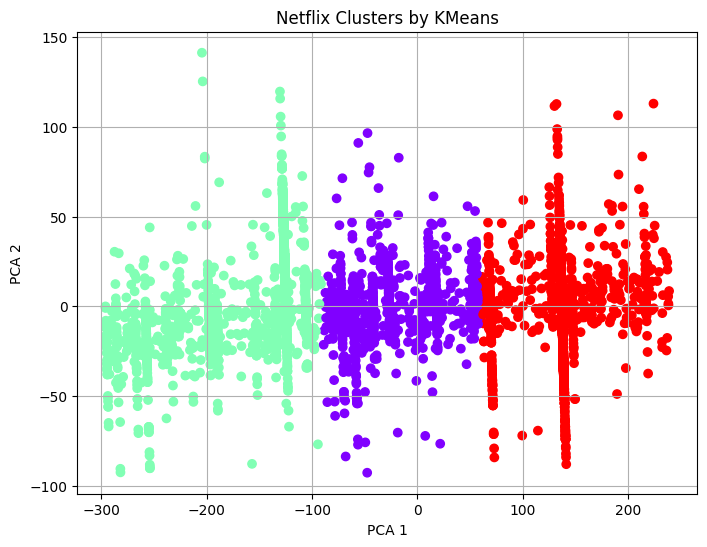

In [22]:

plt.figure(figsize=(8,6))
plt.scatter(pca_features[:, 0], pca_features[:, 1], c=df['cluster'], cmap='rainbow')
plt.title('Netflix Clusters by KMeans')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.grid(True)
plt.show()